In [3]:
#importando as bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl #adiciona a funcionalidade na plotagem
import seaborn as sns 
from sklearn.feature_selection import f_classif
mpl.rcParams['figure.dpi']=400 #figuras em alta resolucao 
from sklearn.feature_selection import SelectPercentile


In [4]:
df = pd.read_csv('Chapter_1_cleaned_data.csv')

In [5]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,EDUCATION_CAT,graduate school,high school,none,others,university
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,1,university,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,1000,0,2000,1,university,0,0,0,0,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,1000,1000,5000,0,university,0,0,0,0,1
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,1100,1069,1000,0,university,0,0,0,0,1
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,9000,689,679,0,university,0,0,0,0,1


In [6]:
items_to_remove = ['ID', 'SEX', 'PAY_2','PAY_3', 'PAY_4','PAY_5','PAY_6','EDUCATION_CAT','graduate school','high school', 'none','others','university'  ]

In [7]:
#fazendo uma tabela tirar as colunas do items_to_remove
feature_response = [col for col in df.columns if col not in items_to_remove]

In [8]:
feature_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [9]:
#Correlação
df.corr()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,graduate school,high school,none,others,university
LIMIT_BAL,1.000000,0.027046,-0.232688,-0.111873,0.149157,-0.273396,-0.296471,-0.286613,-0.269296,-0.249555,...,0.207638,0.202795,0.218082,0.221305,-0.154423,0.260582,-0.139678,-0.002007,0.026224,-0.148892
SEX,0.027046,1.000000,0.014336,-0.031307,-0.088421,-0.058993,-0.070828,-0.067869,-0.060820,-0.055418,...,-0.011542,-0.000199,0.000081,-0.003342,-0.039945,-0.022777,-0.005669,0.005594,0.005437,0.024133
EDUCATION,-0.232688,0.014336,1.000000,-0.137097,0.179035,0.112653,0.129558,0.124114,0.118464,0.105290,...,-0.042349,-0.039319,-0.044946,-0.046859,0.034966,-0.835517,0.689244,0.308571,0.190703,0.198278
MARRIAGE,-0.111873,-0.031307,-0.137097,1.000000,-0.412828,0.019759,0.025096,0.034308,0.033082,0.036830,...,-0.003408,-0.014387,-0.000410,-0.009461,-0.026030,0.137198,-0.092283,-0.015199,0.006647,-0.060549
AGE,0.149157,-0.088421,0.179035,-0.412828,1.000000,-0.044277,-0.054053,-0.055795,-0.054972,-0.059438,...,0.029876,0.025307,0.020541,0.021640,0.014334,-0.096956,0.229301,0.017985,-0.013465,-0.079443
PAY_1,-0.273396,-0.058993,0.112653,0.019759,-0.044277,1.000000,0.675430,0.575617,0.539238,0.509140,...,-0.072682,-0.064112,-0.057021,-0.061031,0.325365,-0.142688,0.059008,-0.011596,-0.028421,0.099034
PAY_2,-0.296471,-0.070828,0.129558,0.025096,-0.054053,0.675430,1.000000,0.764960,0.659844,0.620211,...,-0.057972,-0.047047,-0.035798,-0.038711,0.263649,-0.169756,0.063009,-0.016974,-0.033740,0.123824
PAY_3,-0.286613,-0.067869,0.124114,0.034308,-0.055795,0.575617,0.764960,1.000000,0.776238,0.686325,...,-0.055098,-0.046136,-0.035672,-0.038332,0.238085,-0.161372,0.063176,-0.018969,-0.031364,0.115777
PAY_4,-0.269296,-0.060820,0.118464,0.033082,-0.054972,0.539238,0.659844,0.776238,1.000000,0.820401,...,-0.070528,-0.044948,-0.034297,-0.030607,0.219889,-0.154019,0.058468,-0.013638,-0.031913,0.111178
PAY_5,-0.249555,-0.055418,0.105290,0.036830,-0.059438,0.509140,0.620211,0.686325,0.820401,1.000000,...,0.010085,-0.057446,-0.033770,-0.026060,0.204948,-0.139655,0.049600,-0.013954,-0.028813,0.103665


<AxesSubplot:>

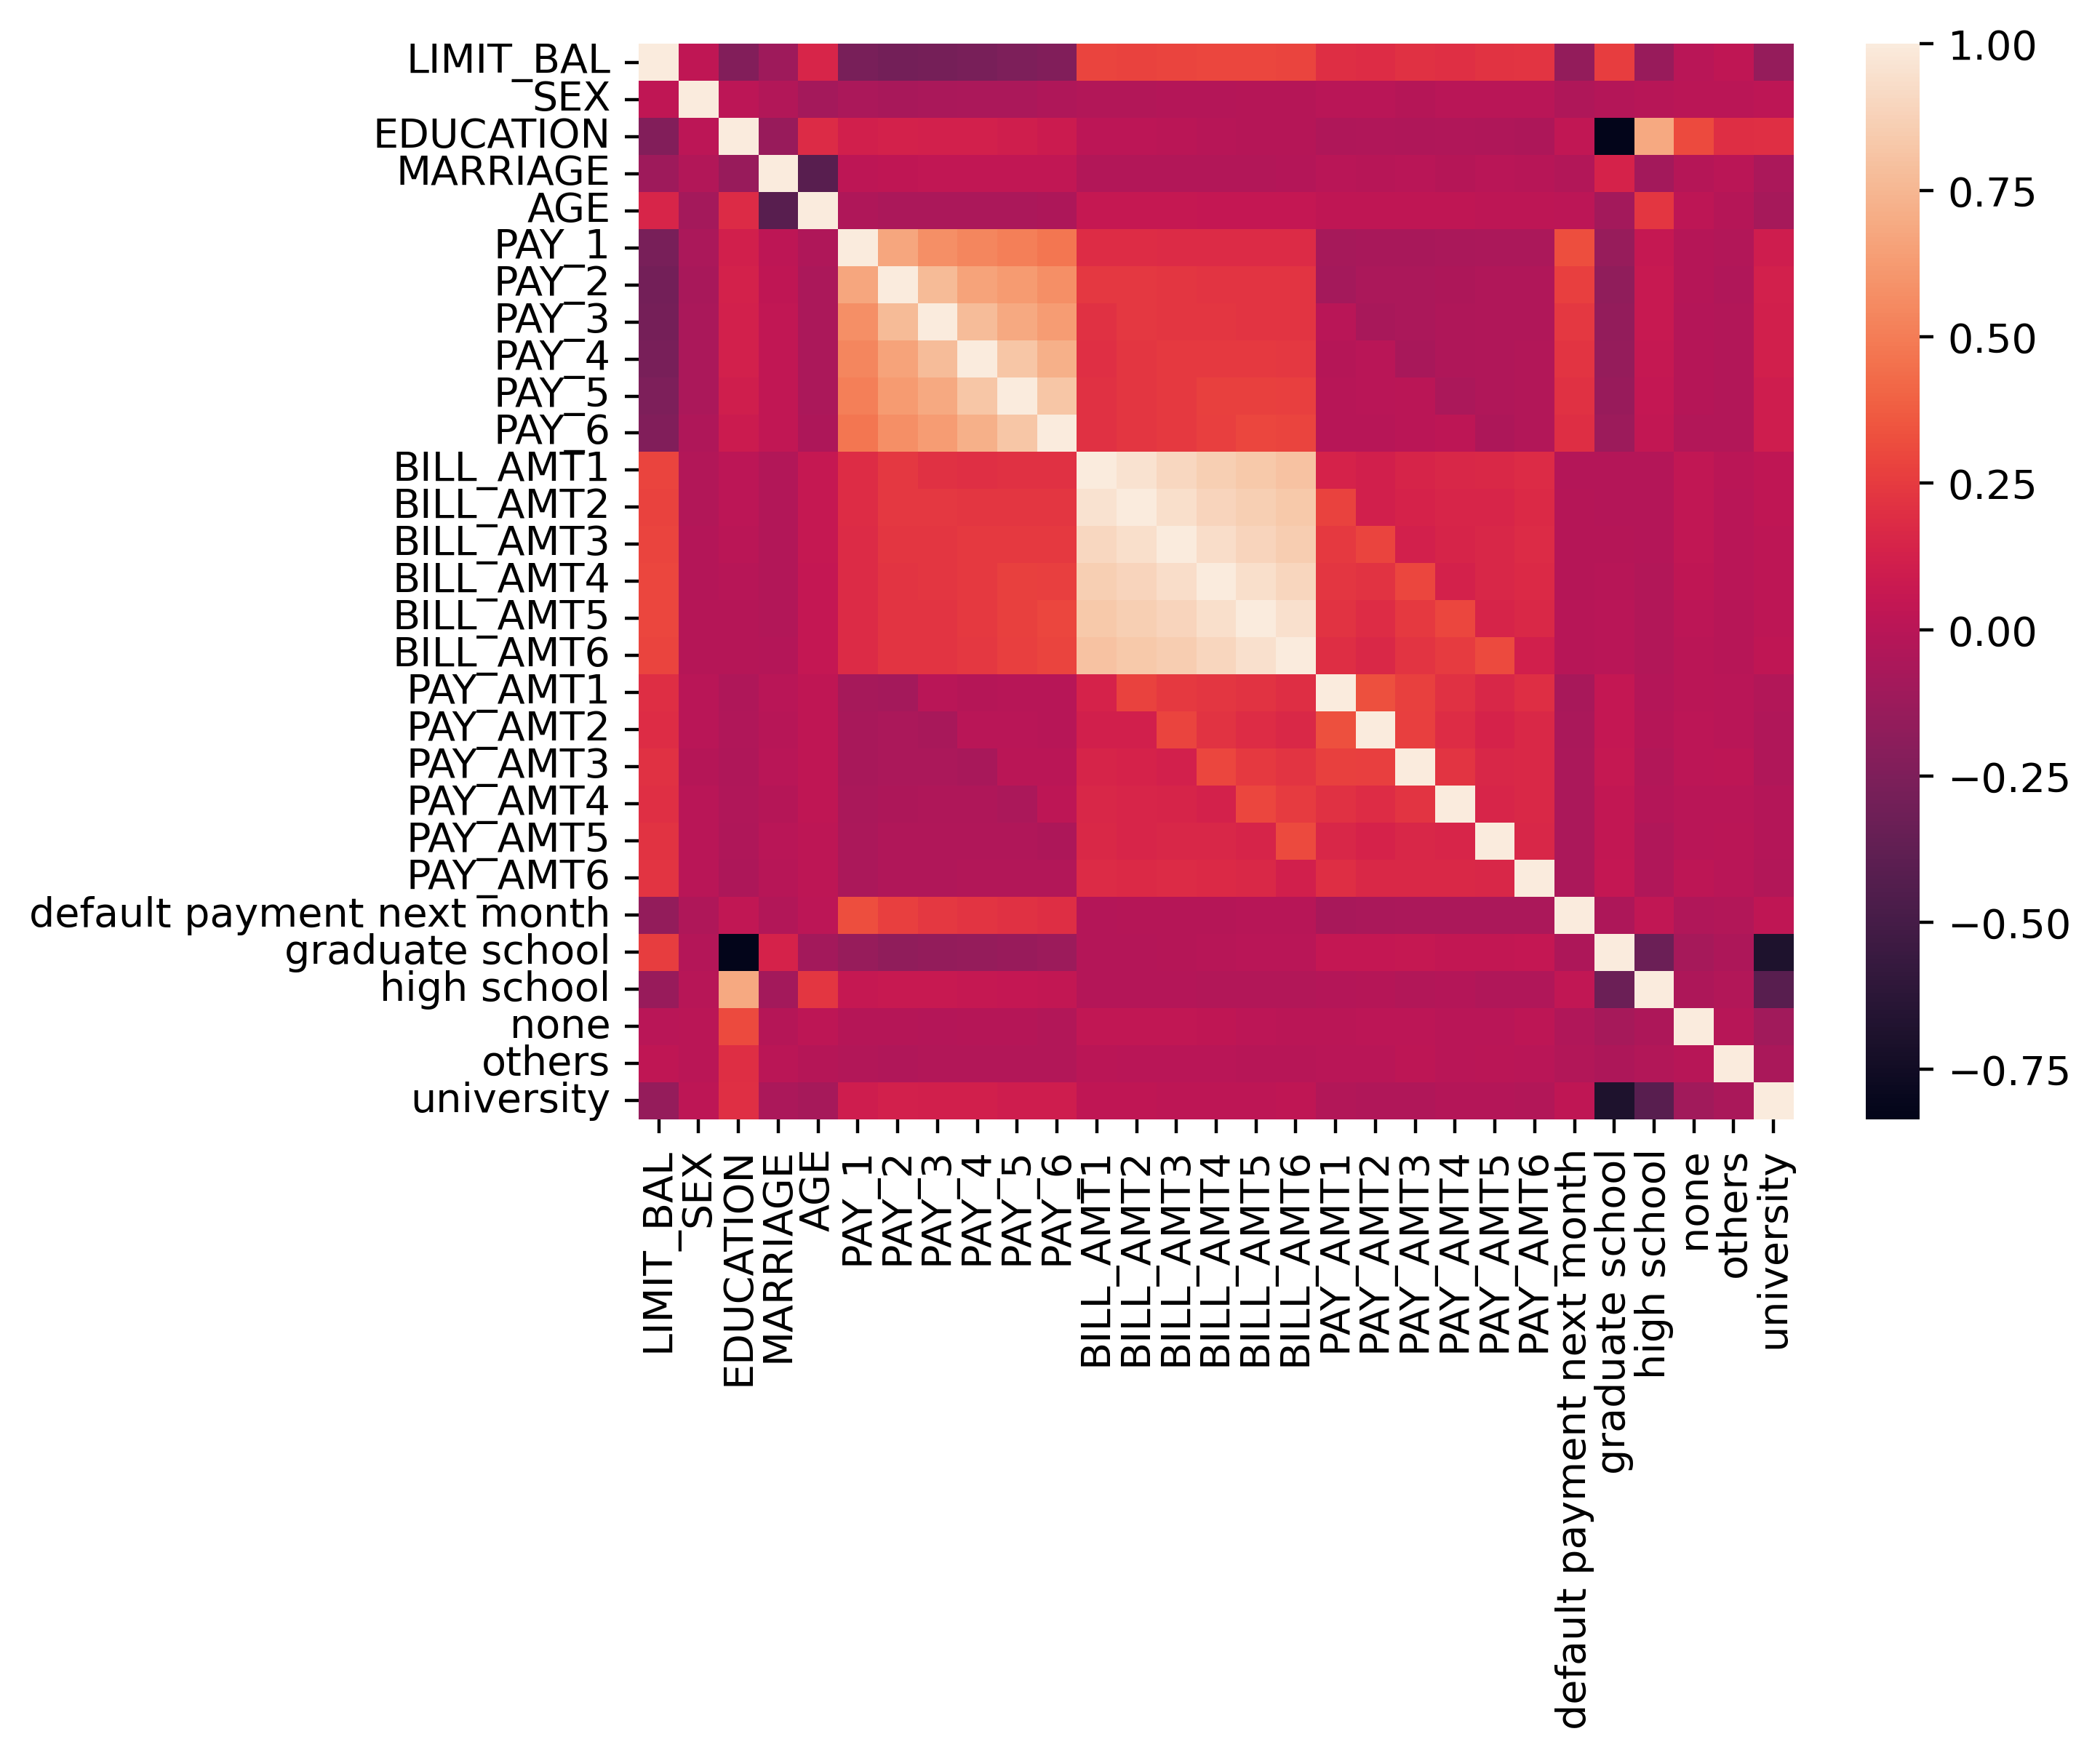

In [10]:
corr = df.corr()
sns.heatmap(corr,xticklabels=corr.columns.values,yticklabels=corr.columns.values)

In [11]:
corr['default payment next month'].abs().sort_values(ascending=False)

default payment next month    1.000000
PAY_1                         0.325365
PAY_2                         0.263649
PAY_3                         0.238085
PAY_4                         0.219889
PAY_5                         0.204948
PAY_6                         0.190182
LIMIT_BAL                     0.154423
PAY_AMT1                      0.072431
PAY_AMT2                      0.061555
PAY_AMT3                      0.058010
PAY_AMT5                      0.056651
PAY_AMT6                      0.054838
PAY_AMT4                      0.054572
graduate school               0.049595
SEX                           0.039945
none                          0.036278
high school                   0.035943
EDUCATION                     0.034966
university                    0.031817
MARRIAGE                      0.026030
others                        0.025494
BILL_AMT1                     0.020508
BILL_AMT3                     0.014649
BILL_AMT2                     0.014579
AGE                      

In [12]:
#O pearson não é muito indicado para casos binários como o nosso, será realizado o teste F ANOVA e o primeiro passo é separar
#as características e a resposta como arrays NumPy usando a lista 

TARGET_NAME = 'default payment next month'

x=df[feature_response].drop(columns=[TARGET_NAME]).values
y=df[TARGET_NAME].values
print(x.shape, y.shape)

(26664, 17) (26664,)


In [13]:
[f_stat, f_p_value]=f_classif(x,y)
f_classif(x,y)

(array([6.51324071e+02, 3.26377679e+01, 1.80780265e+01, 5.47913953e+00,
        3.15667230e+03, 1.12184060e+01, 5.66845420e+00, 5.72293789e+00,
        3.43474047e+00, 1.21608188e+00, 1.04956059e+00, 1.40612679e+02,
        1.01408321e+02, 9.00238734e+01, 7.96400211e+01, 8.58432945e+01,
        8.04207840e+01]),
 array([5.83836587e-142, 1.12217491e-008, 2.12755520e-005, 1.92520602e-002,
        0.00000000e+000, 8.11022595e-004, 1.72796505e-002, 1.67515708e-002,
        6.38496543e-002, 2.70140911e-001, 3.05617603e-001, 2.35835447e-032,
        8.25612412e-024, 2.54264104e-021, 4.77411188e-019, 2.09011996e-020,
        3.21956535e-019]))

In [14]:
pd.DataFrame({'Feature':feature_response[:-1],
             'F statistic': f_stat,
             'p value': f_p_value}).sort_values(by='p value')

,Feature,F statistic,p value
4,PAY_1,3156.672300,0.000000e+00
0,LIMIT_BAL,651.324071,5.838366e-142
11,PAY_AMT1,140.612679,2.358354e-32
12,PAY_AMT2,101.408321,8.256124e-24
13,PAY_AMT3,90.023873,2.542641e-21
15,PAY_AMT5,85.843295,2.090120e-20
16,PAY_AMT6,80.420784,3.219565e-19
14,PAY_AMT4,79.640021,4.774112e-19
1,EDUCATION,32.637768,1.122175e-08
2,MARRIAGE,18.078027,2.127555e-05


In [15]:
selector = SelectPercentile(f_classif,percentile=20)

In [16]:
selector.fit(x,y)

SelectPercentile(percentile=20)

In [17]:
best_feature_ix = selector.get_support()

In [18]:
best_feature_ix

array([ True, False, False, False,  True, False, False, False, False,
       False, False,  True,  True, False, False, False, False])

In [19]:
features = feature_response[:-1]

In [20]:
#mostrando as melhores features de acordo com o teste F
best_features = [features[counter] for counter in range (len(features))
                if best_feature_ix[counter]]

In [21]:
best_features

['LIMIT_BAL', 'PAY_1', 'PAY_AMT1', 'PAY_AMT2']

In [22]:
#taxa de pessoas inadimplentes
overall_default_rate = df['default payment next month'].mean()
overall_default_rate

0.2217971797179718

In [23]:
group_by_pay_mean_y = df.groupby('PAY_1').agg({TARGET_NAME:np.mean})

In [24]:
group_by_pay_mean_y 

,default payment next month
PAY_1,
-2,0.131664
-1,0.170002
0,0.128295
1,0.336400
2,0.694701
3,0.773973
4,0.682540
5,0.434783
6,0.545455


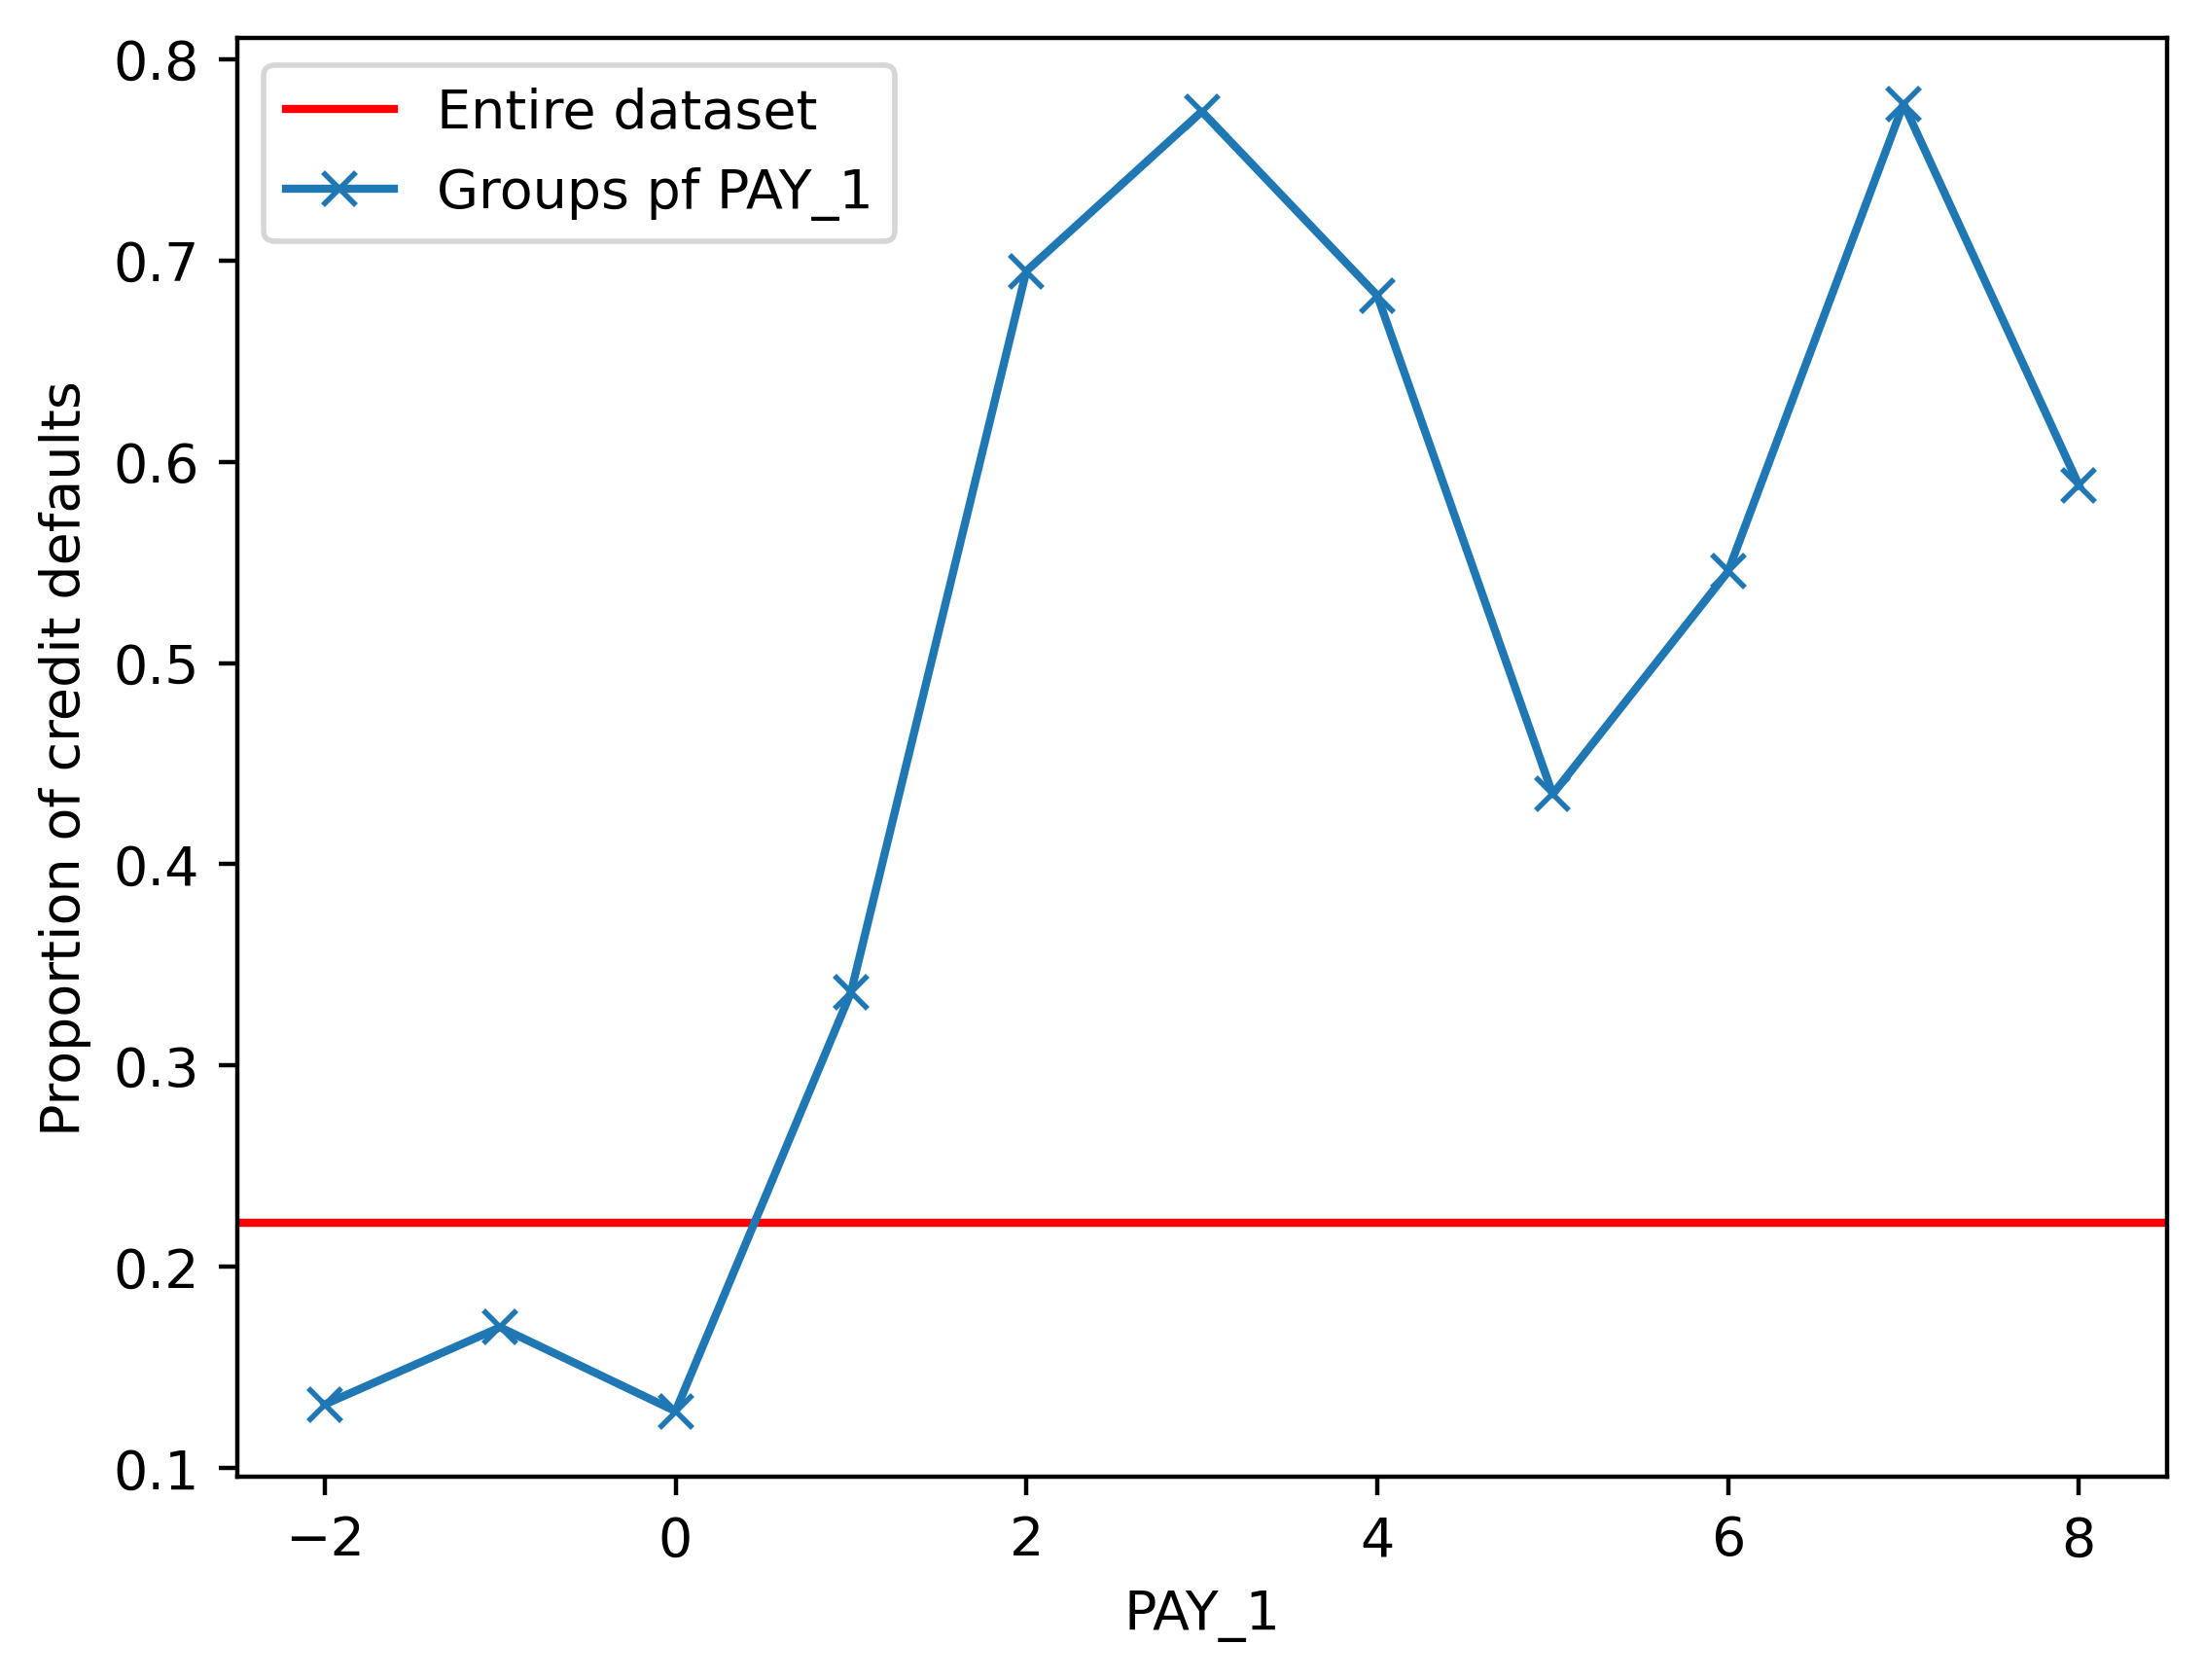

In [25]:
axes = plt.axes ()
axes.axhline(overall_default_rate, color='red')
group_by_pay_mean_y.plot(marker='x', legend=False,ax=axes)
axes.set_ylabel('Proportion of credit defaults')
axes.legend(['Entire dataset','Groups pf PAY_1'])

In [26]:
pos_mask = y == 1
neg_mask = y == 0

Text(0.5, 1.0, 'Credit limits by response variable')

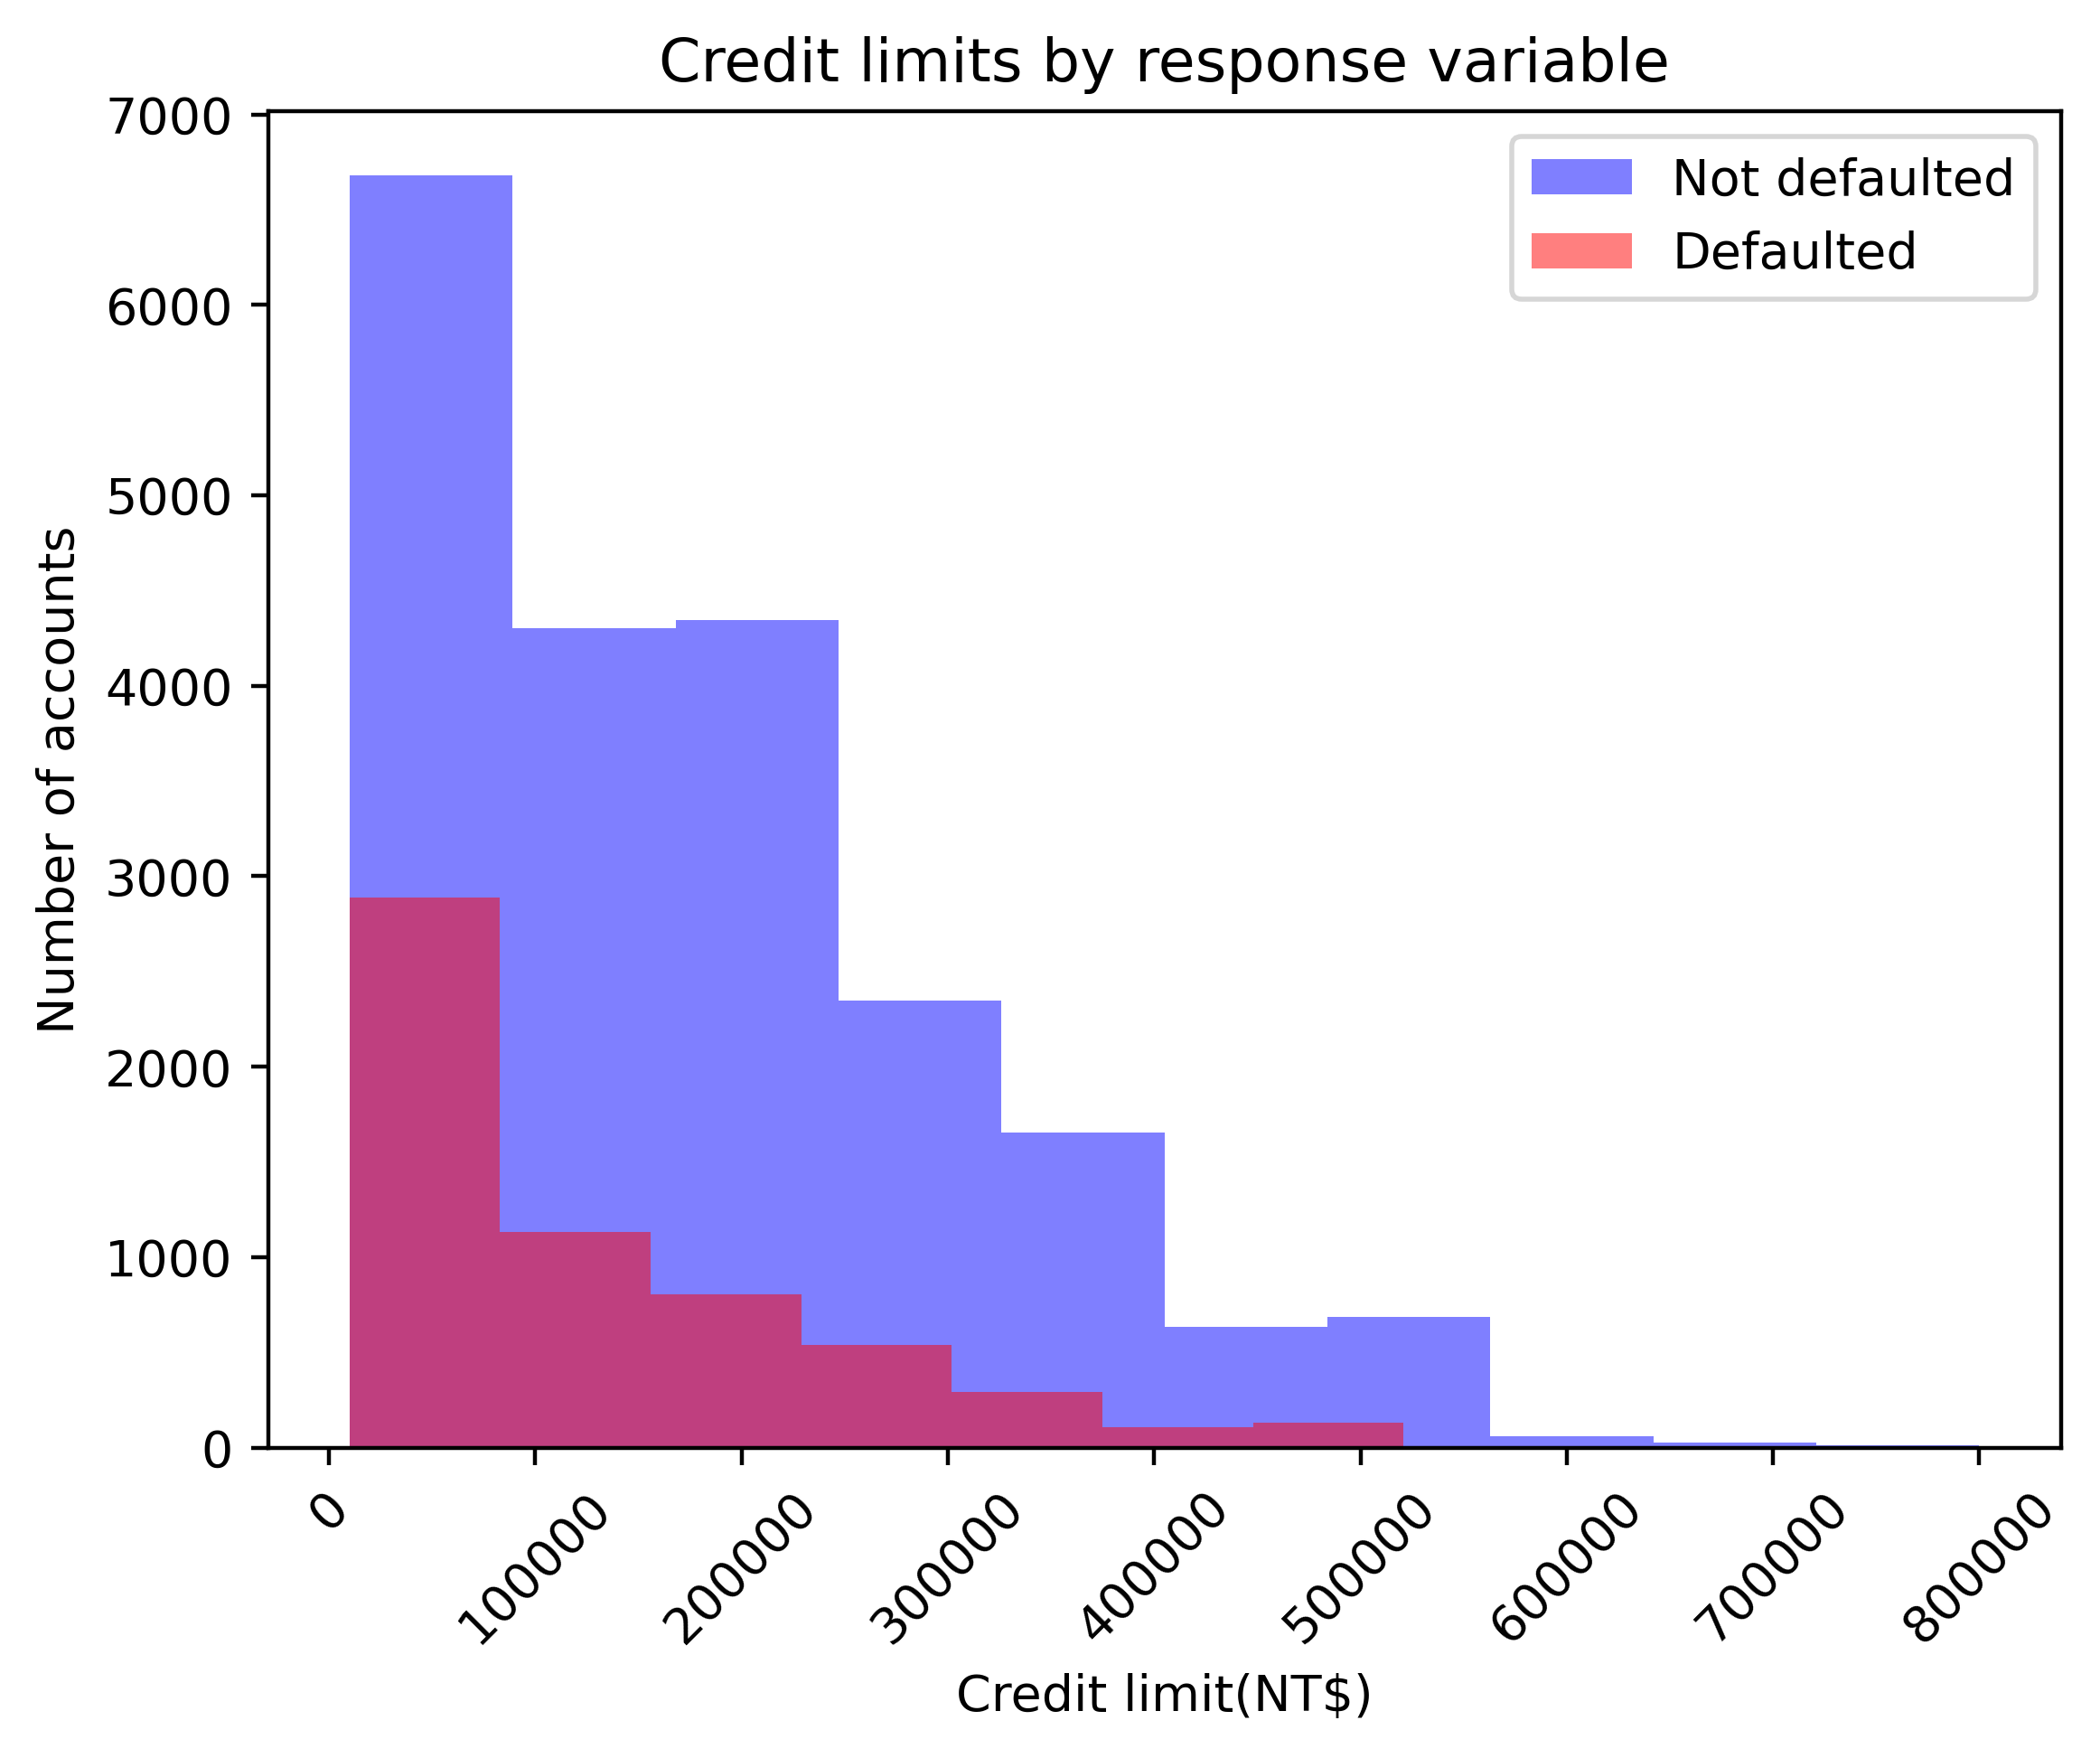

In [27]:
axes = plt.axes()
axes.hist(df.loc[neg_mask,'LIMIT_BAL'], alpha=0.5, color='blue')
axes.hist(df.loc[pos_mask,'LIMIT_BAL'], alpha=0.5,color='red')
axes.tick_params(axis='x',labelrotation=45)
axes.set_xlabel('Credit limit(NT$)')
axes.set_ylabel('Number of accounts')
axes.legend(['Not defaulted', 'Defaulted'])
axes.set_title('Credit limits by response variable')

In [28]:
df['LIMIT_BAL'].max()

800000

In [29]:
bin_edges = list(range(0,850000,50000))
print(bin_edges)

[0, 50000, 100000, 150000, 200000, 250000, 300000, 350000, 400000, 450000, 500000, 550000, 600000, 650000, 700000, 750000, 800000]


C:\Users\Ludmila\AppData\Local\Temp\ipykernel_15180\1894827437.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes.set_yticklabels(np.round(y_ticks*50000,2))


Text(0.5, 1.0, 'Normalized distributions of credit limits by respose variable')

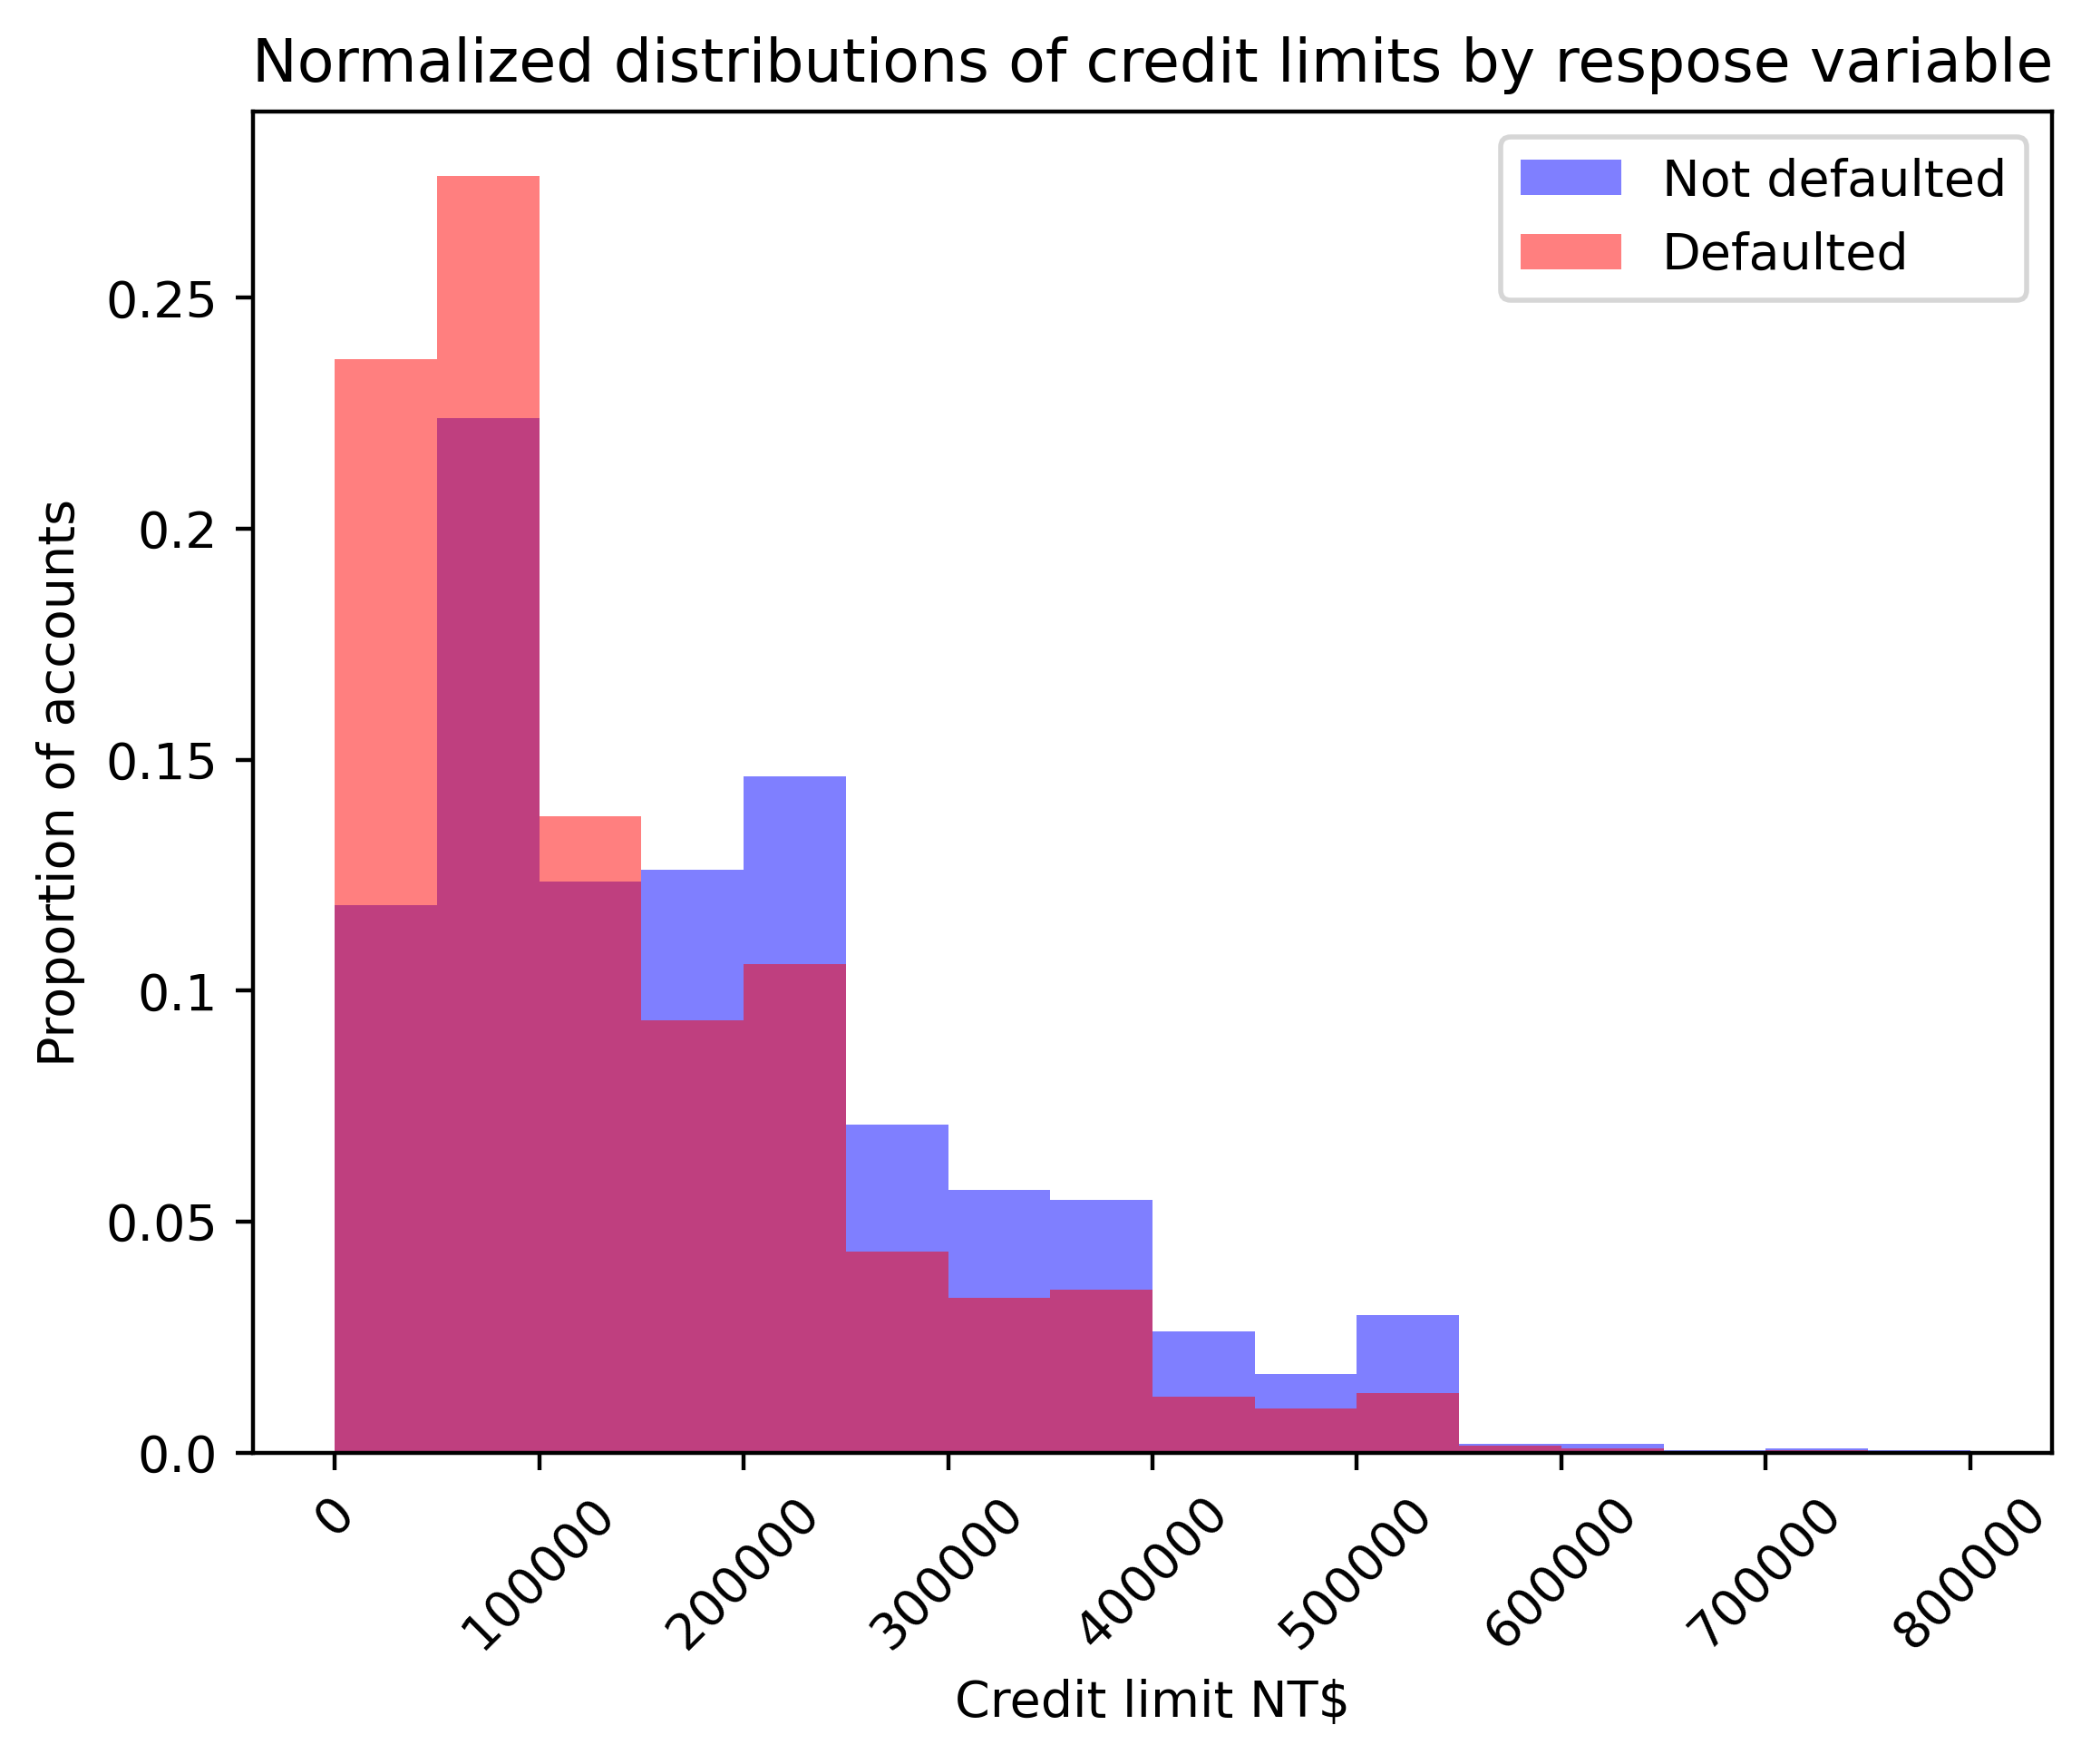

In [30]:
mpl.rcParams['figure.dpi']=400
axes = plt.axes()
axes.hist(df.loc[neg_mask,'LIMIT_BAL'], bins=bin_edges,
          alpha=0.5,density=True,color='blue')

axes.hist(df.loc[pos_mask,'LIMIT_BAL'],bins=bin_edges,
          alpha=0.5,density = True, color='red')
axes.tick_params(axis='x', labelrotation=45)
axes.set_xlabel('Credit limit NT$')
axes.set_ylabel('Proportion of accounts')
y_ticks = axes.get_yticks()
axes.set_yticklabels(np.round(y_ticks*50000,2))
axes.legend(['Not defaulted','Defaulted'])
axes.set_title('Normalized distributions of credit limits by respose variable')

In [31]:
def my_mean (input_argument):
    output = sum(input_argument)/len(input_argument)
    return(output)

In [32]:
my_mean([1,2,3,4,5])

3.0

In [34]:
X_exp = np.linspace(-4,4,81)
print(X_exp[:5])
print(X_exp[-5:])

[-4.  -3.9 -3.8 -3.7 -3.6]
[3.6 3.7 3.8 3.9 4. ]


Text(0.5, 1.0, 'plot of $e^X$')

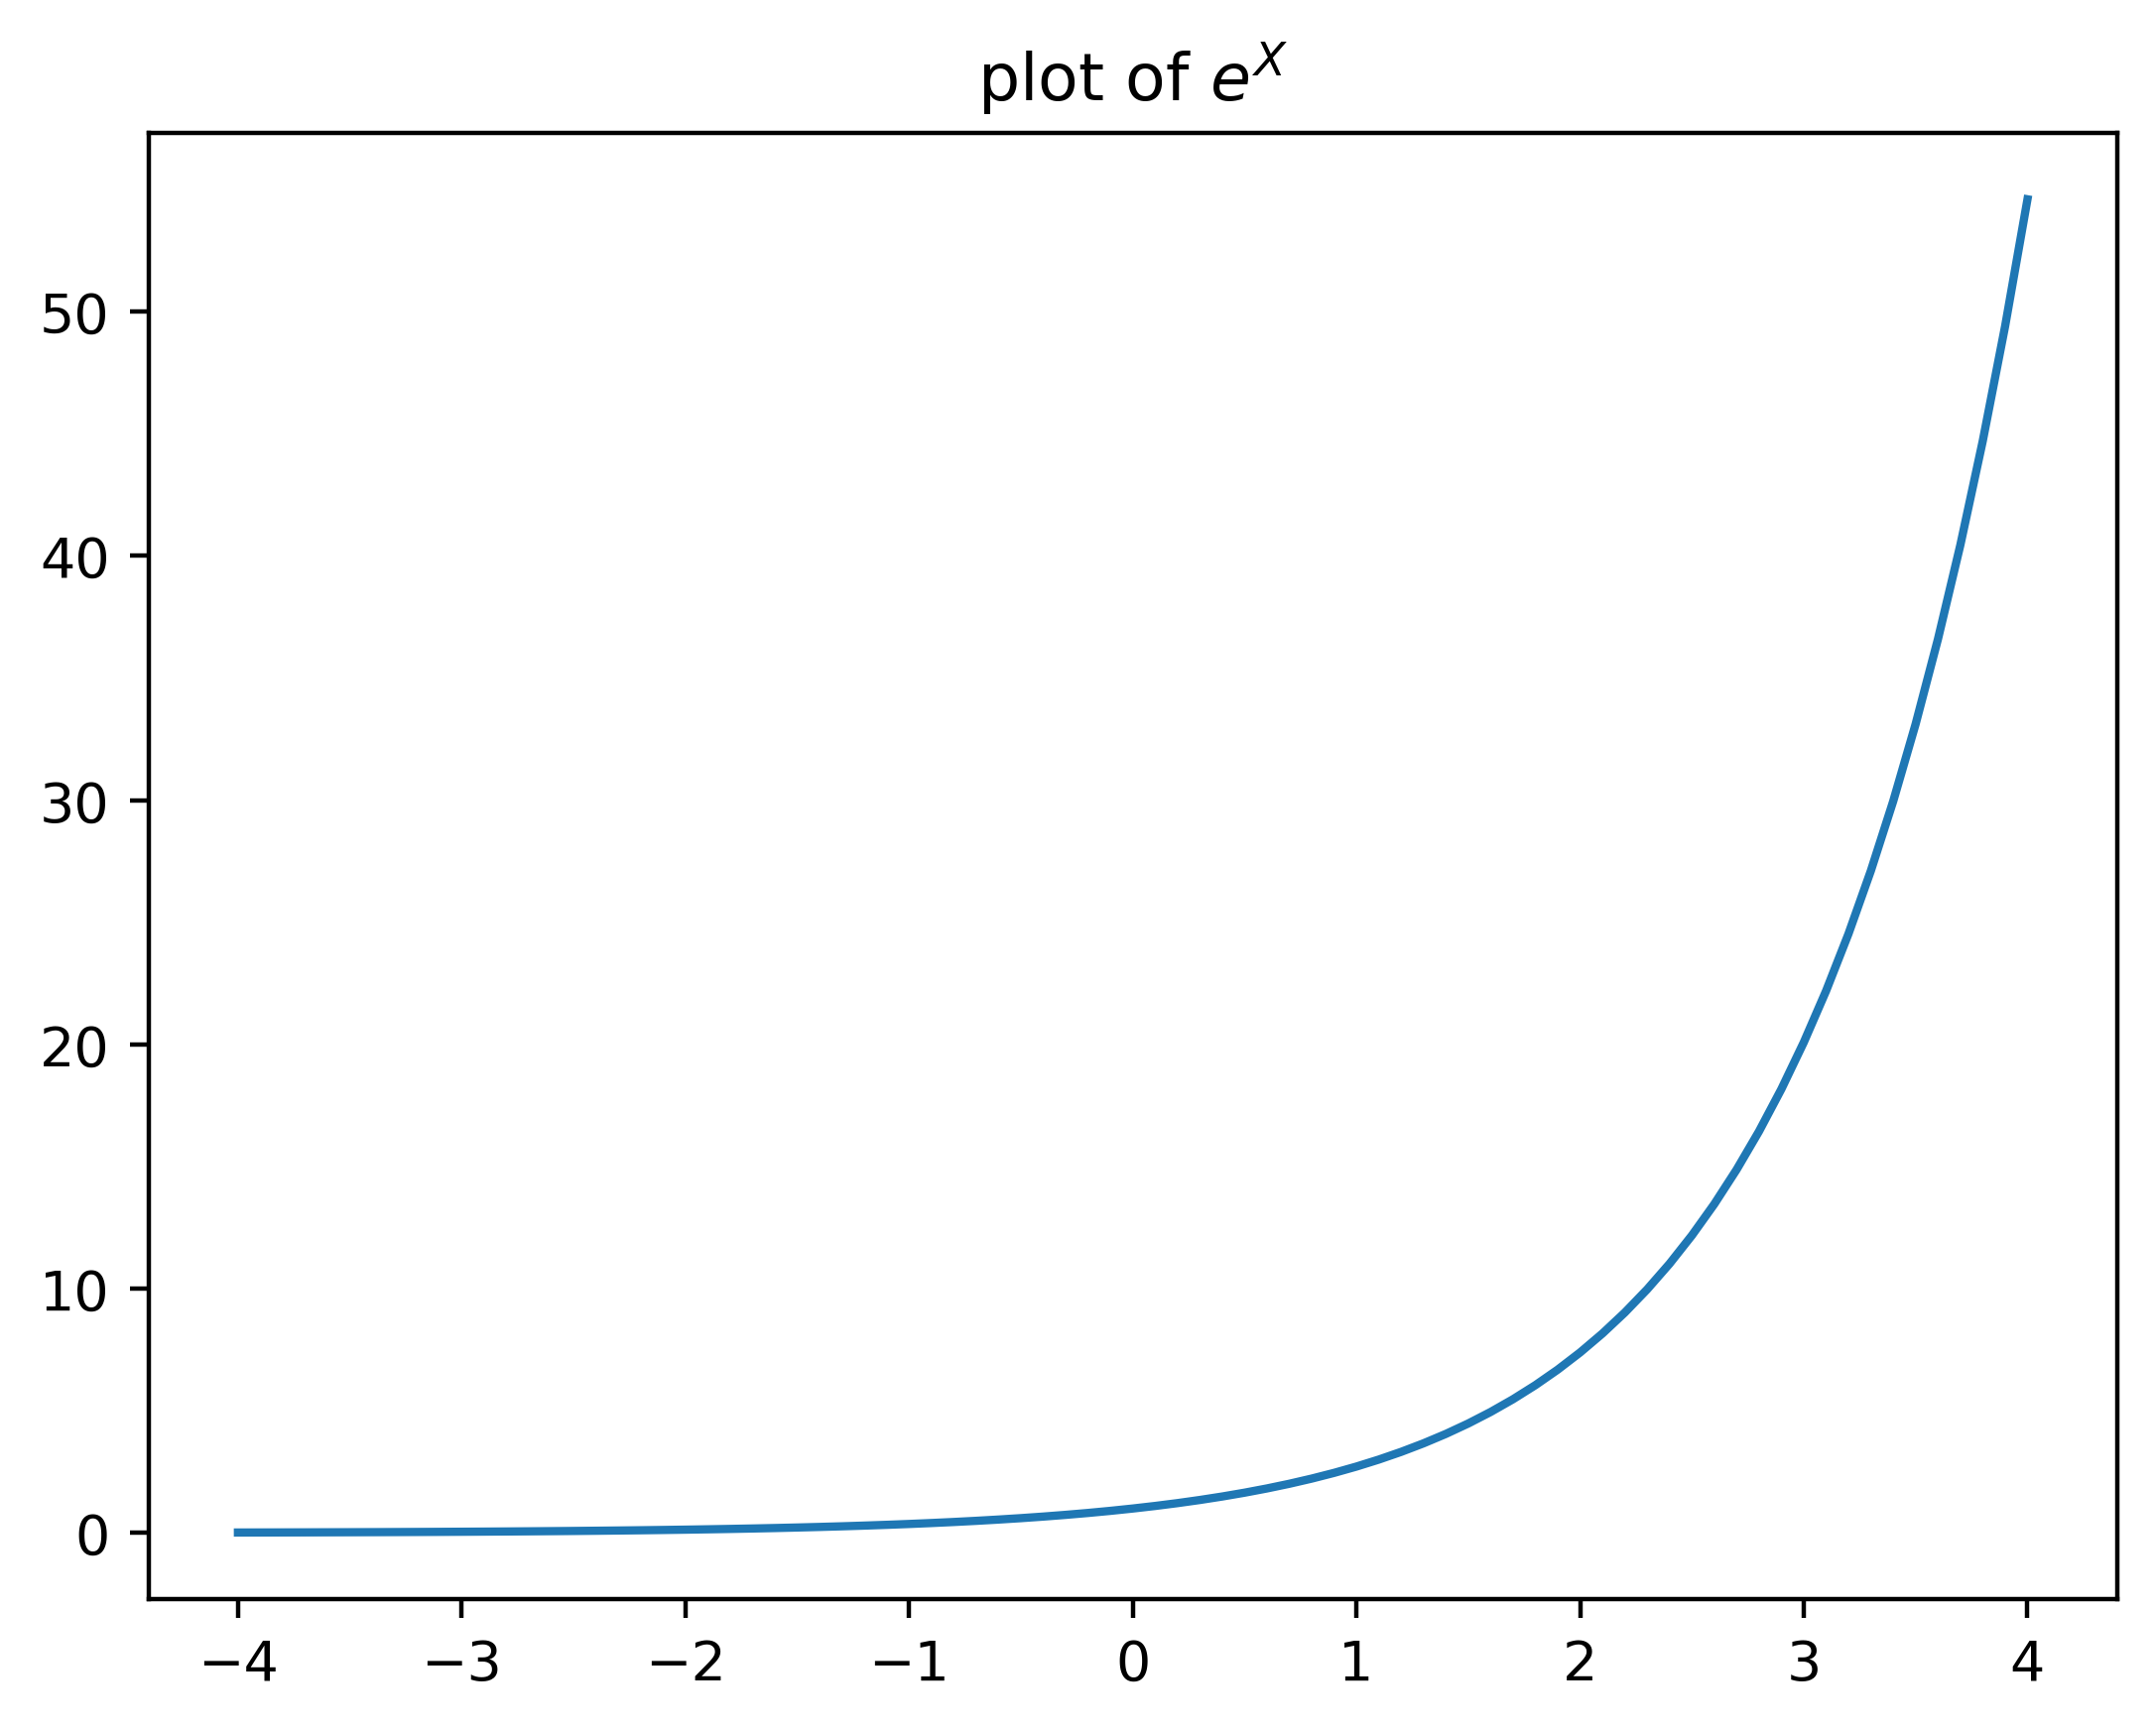

In [36]:
Y_exp=np.exp(X_exp)
plt.plot(X_exp,Y_exp)
plt.title('plot of $e^X$')

In [37]:
Y_exp=np.exp(X_exp)
Y_exp[:5]

array([0.01831564, 0.02024191, 0.02237077, 0.02472353, 0.02732372])

Text(0.5, 1.0, 'Plot de $e^X$')

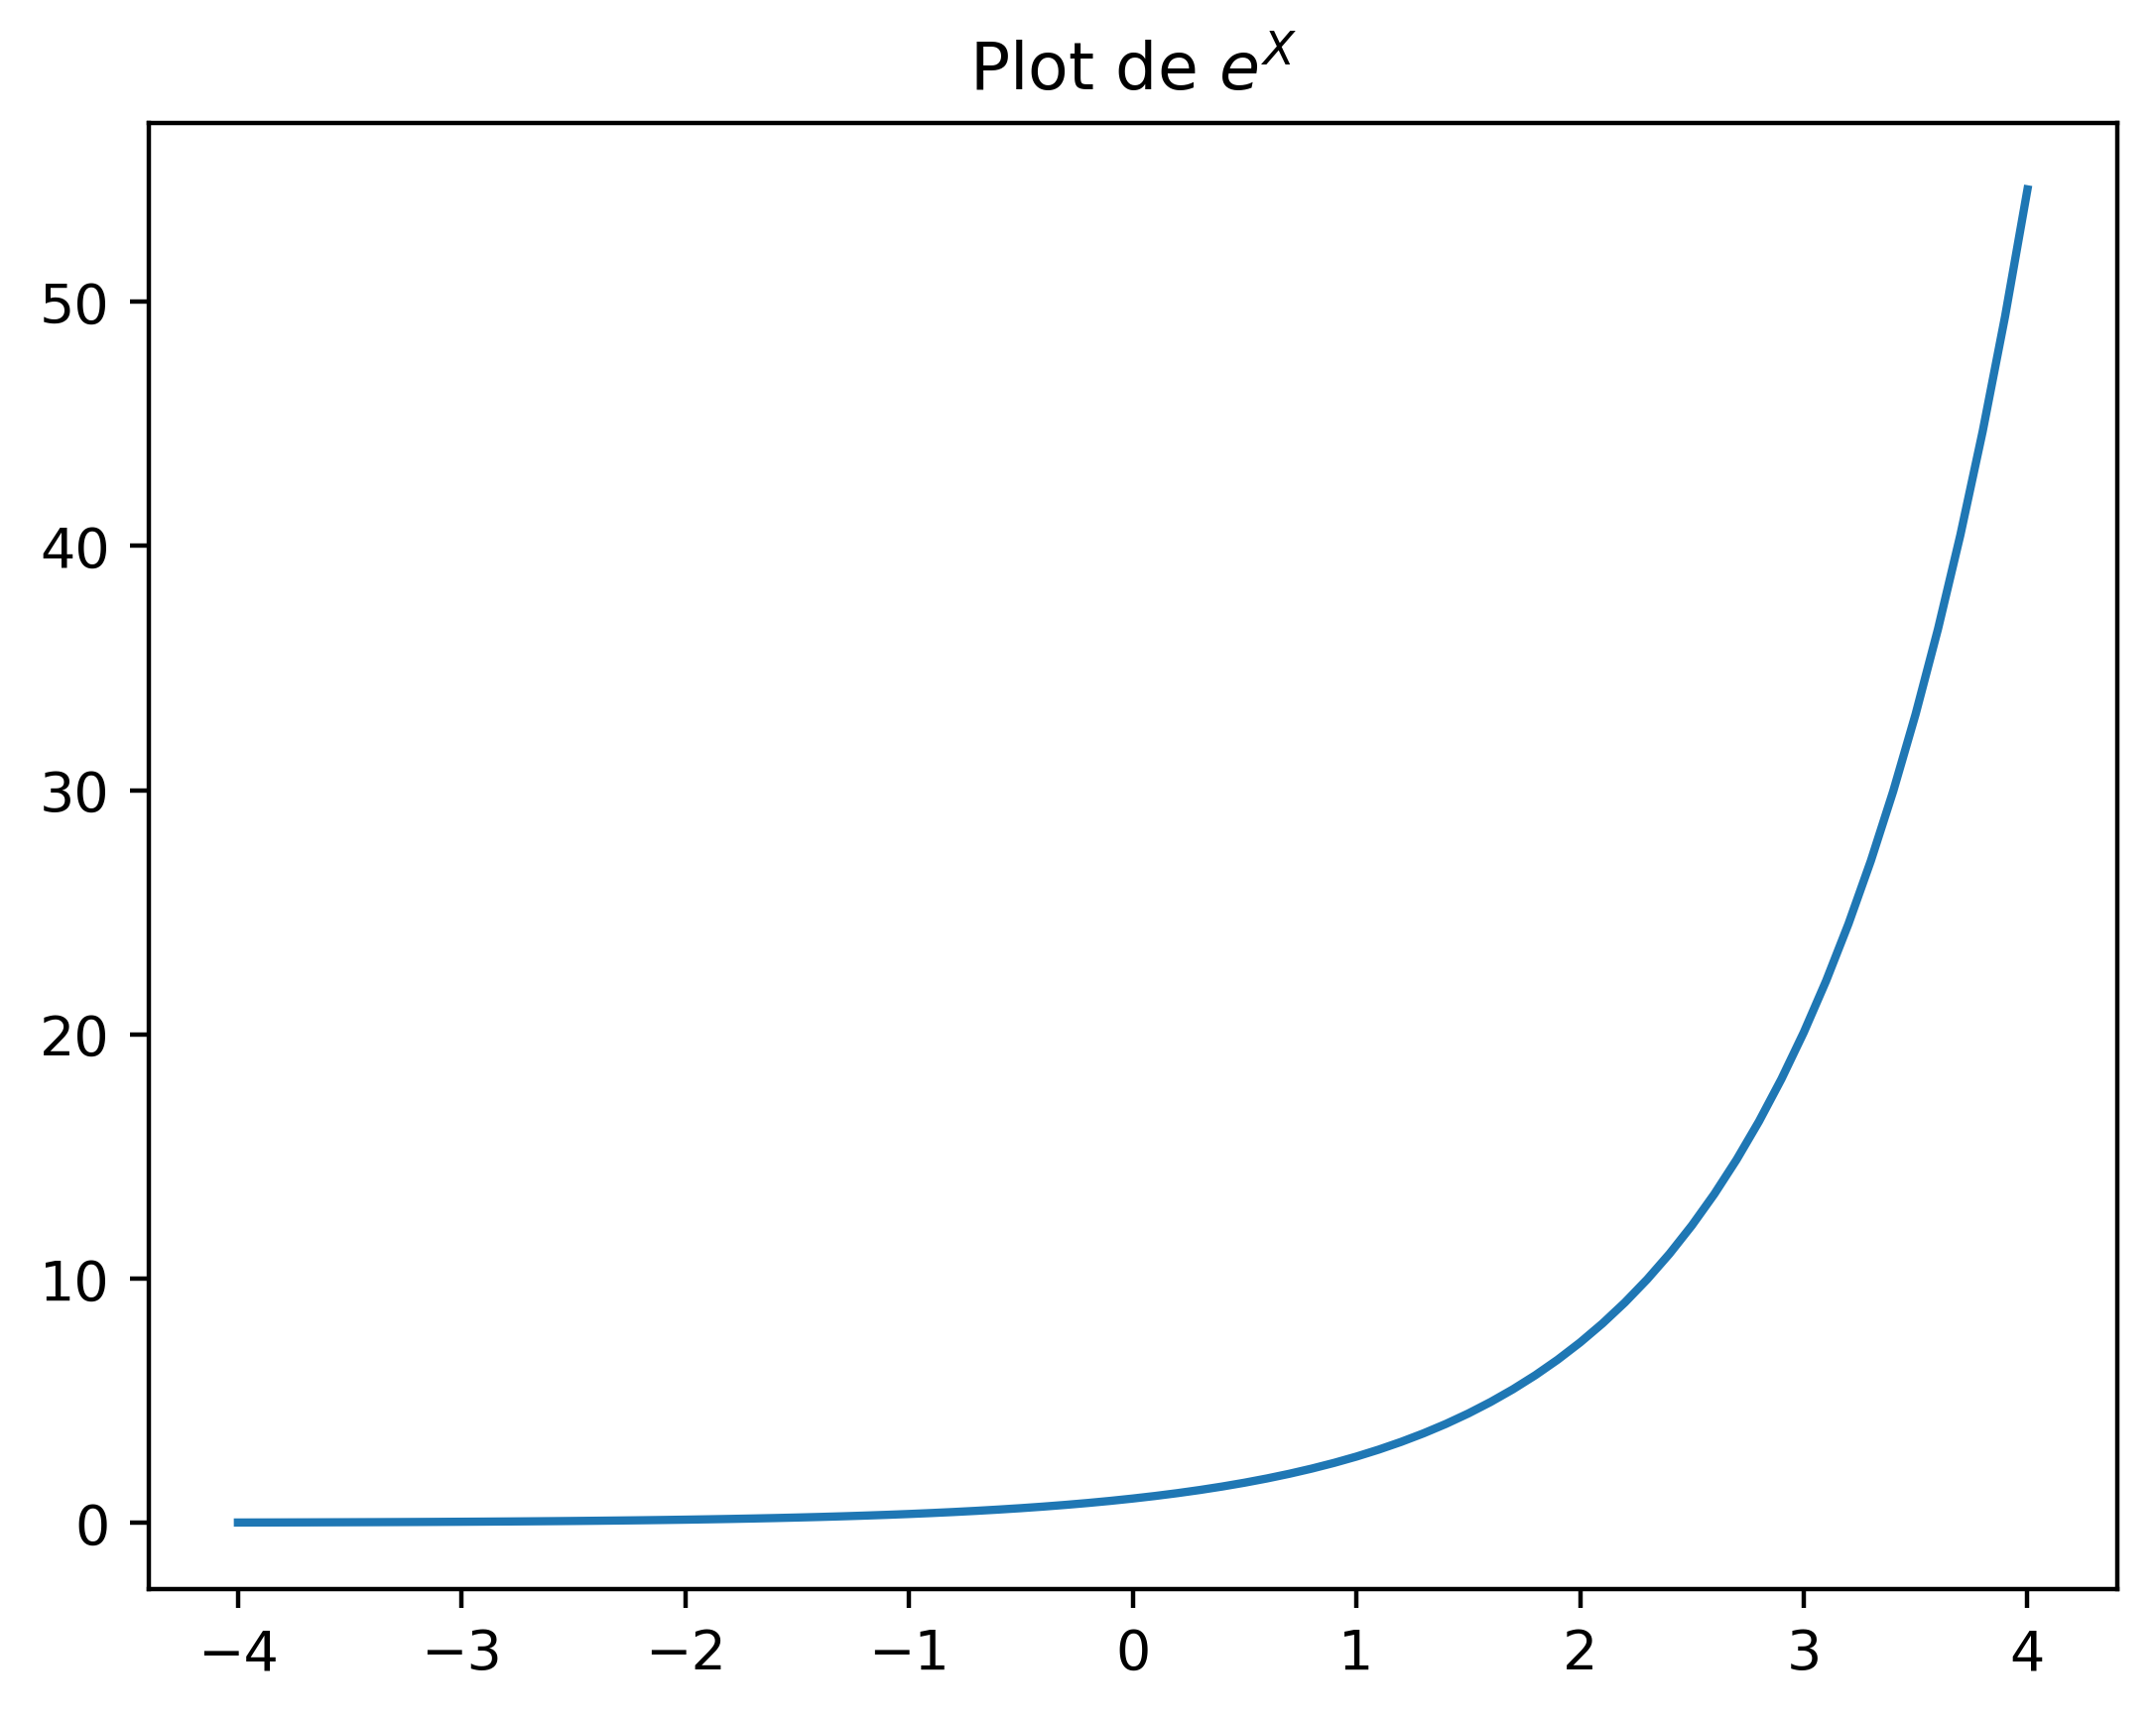

In [40]:
plt.plot(X_exp,Y_exp)
plt.title('Plot de $e^X$')

In [41]:
#O sigmoide é usado em regressão logística - converte uma combinação linear de variáveis em uma probabilidade.
#ex.: chance de um cliente cancelar um serviço
#também usado em redes neurais, historicamente usada como função de ativação, especialmente na camada de saída para problemas de classificação binária
#Portas em LSTMs controla o fluxo de informação em redes neurais recorrentes.

In [42]:
group_by_pay_mean_y

,default payment next month
PAY_1,
-2,0.131664
-1,0.170002
0,0.128295
1,0.336400
2,0.694701
3,0.773973
4,0.682540
5,0.434783
6,0.545455


In [43]:
p=group_by_pay_mean_y['default payment next month'].values

In [44]:
q=1-p

In [45]:
print(q)

[0.86833603 0.82999802 0.87170475 0.66360012 0.30529857 0.2260274
 0.31746032 0.56521739 0.45454545 0.22222222 0.41176471]


In [46]:
odds_ratio = p/q
log_odds=np.log(odds_ratio)
log_odds

array([-1.88632574, -1.58561322, -1.91611649, -0.67937918,  0.82219194,
        1.23088026,  0.76546784, -0.26236426,  0.18232156,  1.25276297,
        0.35667494])

In [47]:
group_by_pay_mean_y.index

Int64Index([-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8], dtype='int64', name='PAY_1')

Text(0.5, 0, 'values of PAY_1')

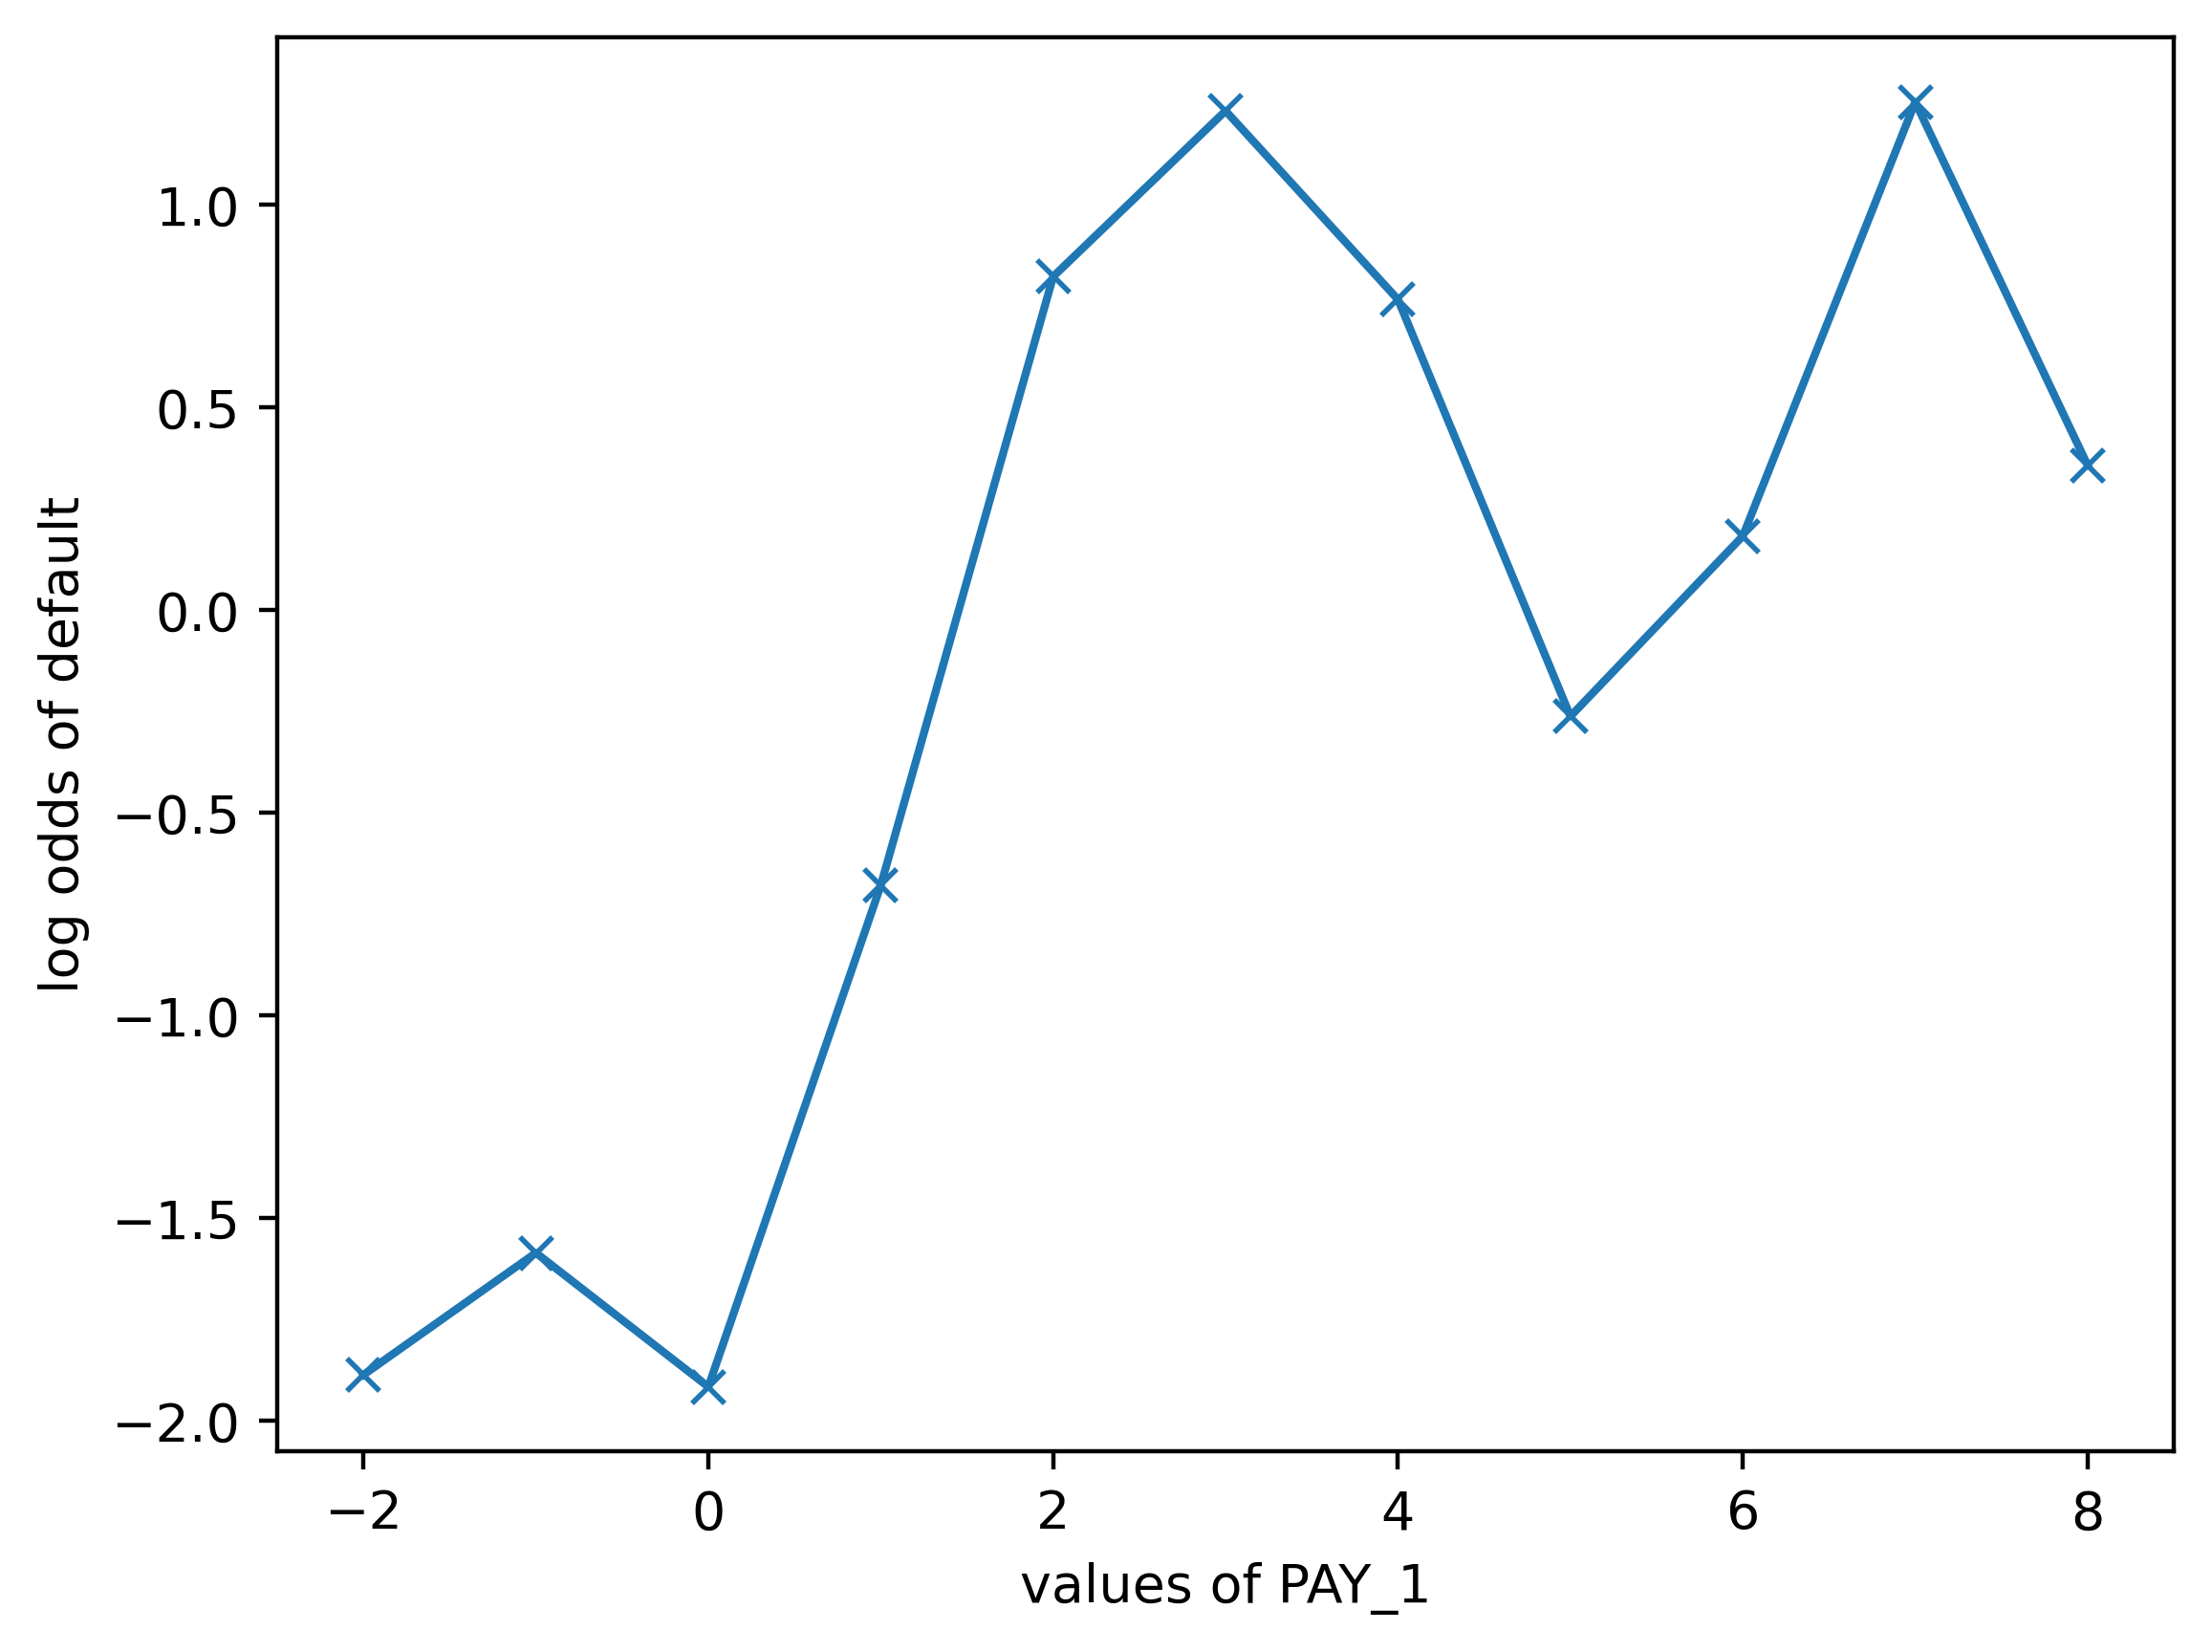

In [51]:
plt.plot(group_by_pay_mean_y.index, log_odds,'-x')
plt.ylabel('log odds of default')
plt.xlabel('values of PAY_1')

Possível ver na plotagem acima, que o relacionamento entre o logaritmo das chances da variável de resposta e a característica PAY_1 não é tão diferente do relacionamentoentre a taxa de inadimplência e essas características. 


In [53]:
np.random.seed(42)
X_1_pos = np.random.uniform(low=1, high=7, size=(20,1))
X_1_neg = np.random.uniform(low=3, high=10, size=(20,1))
X_2_pos = np.random.uniform(low=1, high=7, size=(20,1))
X_2_neg = np.random.uniform(low=3, high=10, size=(20,1))
print(X_1_neg[0:3])

[[7.28297026]
 [3.97645702]
 [5.04501254]]


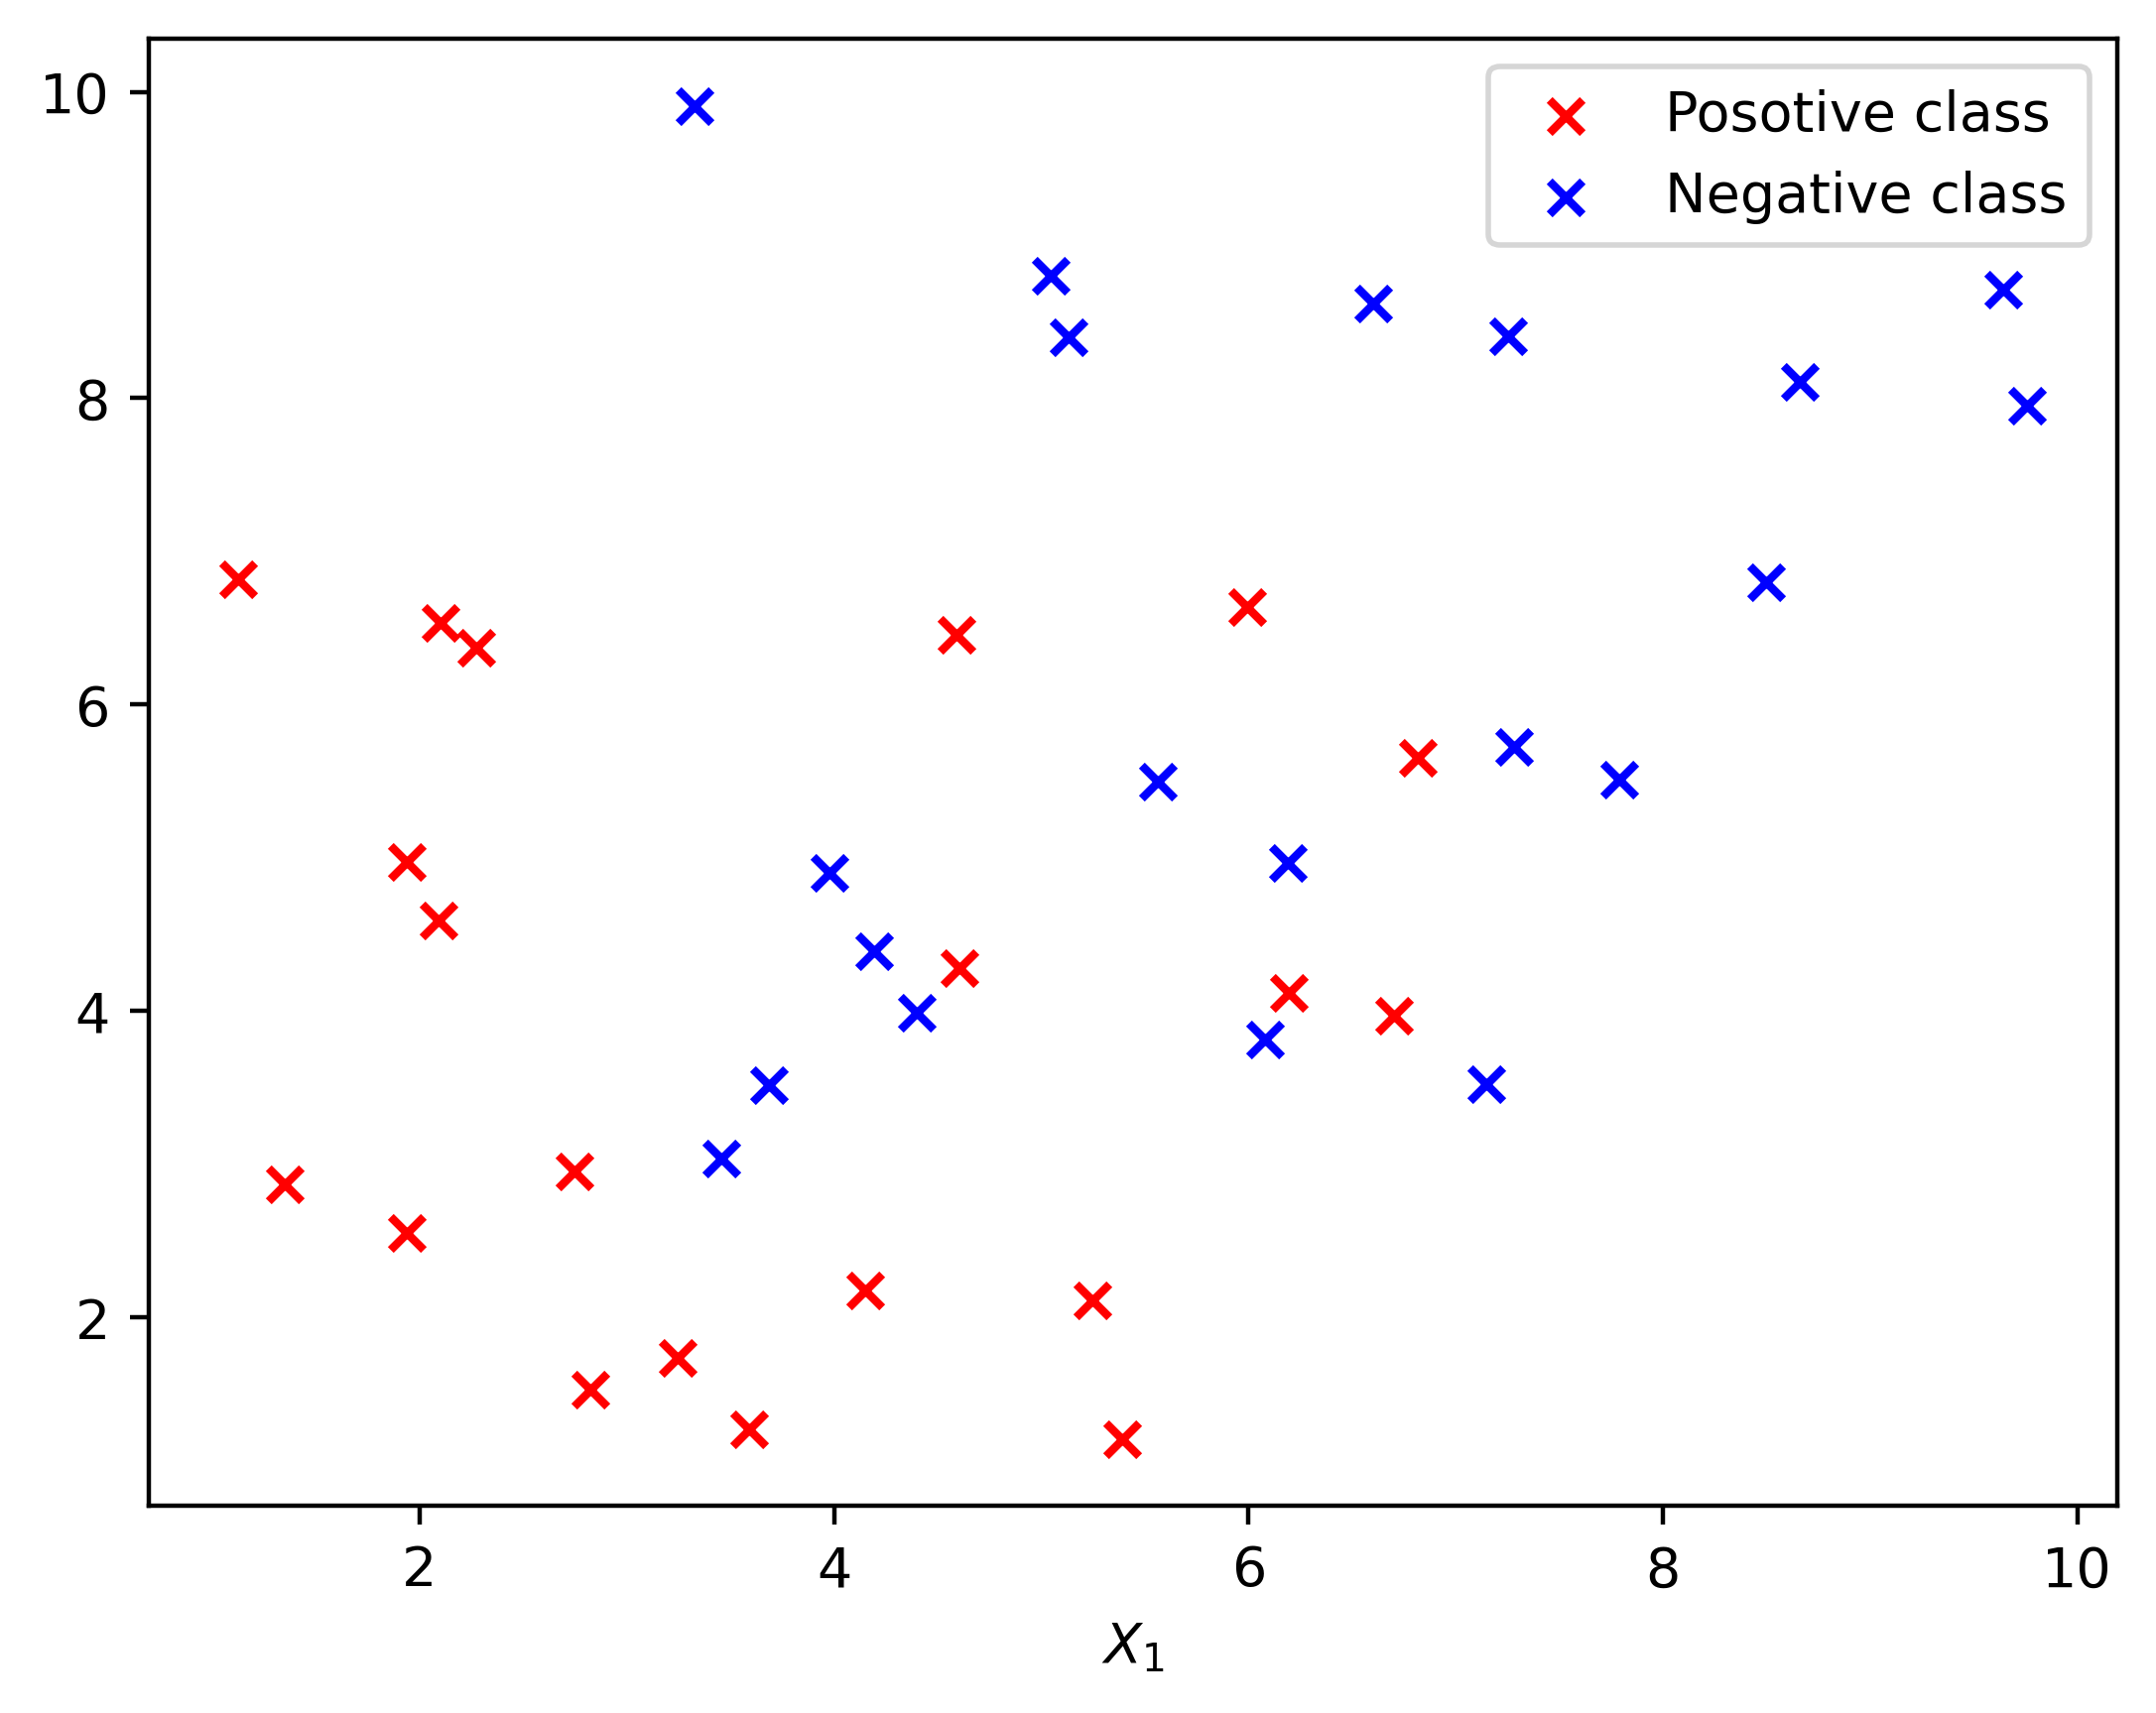

In [56]:
plt.scatter(X_1_pos,X_2_pos, color='red', marker='x')
plt.scatter(X_1_neg,X_2_neg, color='blue', marker='x')
plt.xlabel('$X_1$')
plt.legend(['Posotive class', 'Negative class'])